# Exploratory analysis / diagnostics

In [2]:
import pandas as pd
import numpy as np
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

In [3]:
# read in data
reviews = gpd.read_file("data/neigh_reviews_subset.gpkg")
# drop existing neighborhood-level gentrification indicators
reviews = reviews.drop(columns="gentrified")
reviews.head()

,business_id,name,address,city,state,postal_code_x,latitude,longitude,stars,review_count,...,index_right,LISTNAME,review_id,user_id,useful,funny,cool,text,date,geometry
0,MTSW4McQd7CbVtyjqoe9mw,St Honore Pastries,935 Race St,Philadelphia,PA,19107,39.955505,-75.155564,4.0,80,...,92.0,Chinatown,BXQcBN0iAi1lAUxibGLFzA,6_SpY41LIHZuIaiDs5FMKA,0.0,0.0,1.0,This is nice little Chinese bakery in the hear...,2014-05-26 01:09:53,POINT (-75.15556 39.95551)
1,MTSW4McQd7CbVtyjqoe9mw,St Honore Pastries,935 Race St,Philadelphia,PA,19107,39.955505,-75.155564,4.0,80,...,92.0,Chinatown,uduvUCvi9w3T2bSGivCfXg,tCXElwhzekJEH6QJe3xs7Q,3.0,1.0,2.0,This is the bakery I usually go to in Chinatow...,2013-10-05 15:19:06,POINT (-75.15556 39.95551)
2,MTSW4McQd7CbVtyjqoe9mw,St Honore Pastries,935 Race St,Philadelphia,PA,19107,39.955505,-75.155564,4.0,80,...,92.0,Chinatown,a0vwPOqDXXZuJkbBW2356g,WqfKtI-aGMmvbA9pPUxNQQ,0.0,0.0,0.0,"A delightful find in Chinatown! Very clean, an...",2013-10-25 01:34:57,POINT (-75.15556 39.95551)
3,MTSW4McQd7CbVtyjqoe9mw,St Honore Pastries,935 Race St,Philadelphia,PA,19107,39.955505,-75.155564,4.0,80,...,92.0,Chinatown,MKNp_CdR2k2202-c8GN5Dw,3-1va0IQfK-9tUMzfHWfTA,5.0,0.0,5.0,I ordered a graduation cake for my niece and i...,2018-05-20 17:58:57,POINT (-75.15556 39.95551)
4,MTSW4McQd7CbVtyjqoe9mw,St Honore Pastries,935 Race St,Philadelphia,PA,19107,39.955505,-75.155564,4.0,80,...,92.0,Chinatown,D1GisLDPe84Rrk_R4X2brQ,EouCKoDfzaVG0klEgdDvCQ,2.0,1.0,1.0,HK-STYLE MILK TEA: FOUR STARS\n\nNot quite su...,2013-10-25 02:31:35,POINT (-75.15556 39.95551)


In [4]:
# check the columns
reviews.columns

Index(['business_id', 'name', 'address', 'city', 'state', 'postal_code_x',
       'latitude', 'longitude', 'stars', 'review_count', 'is_open',
       'attributes', 'categories', 'hours', 'index_right', 'LISTNAME',
       'review_id', 'user_id', 'useful', 'funny', 'cool', 'text', 'date',
       'geometry'],
      dtype='object')

## Subset to brewery reviews

In [5]:
# turn the strings in 'categories' to lowercase to make things easier
reviews['categories'] = reviews['categories'].str.lower()

# check out the unique values of reviews containing "brew"
reviews[reviews['categories'].str.contains("brew")]['categories'].unique()

array(['eatertainment, arts & entertainment, brewpubs, american (traditional), bakeries, breweries, food, restaurants',
       'nightlife, music venues, irish, pubs, irish pub, arts & entertainment, food, restaurants, breweries, bars, beer, wine & spirits',
       'food, restaurants, breweries, bars, nightlife',
       'breweries, brewpubs, food, hot dogs, restaurants, sandwiches',
       'american (new), bars, food, pubs, breweries, pizza, restaurants, nightlife',
       'food, breweries, restaurants',
       'brewpubs, food, restaurants, american (traditional), breweries',
       'american (traditional), nightlife, food, bars, restaurants, beer, wine & spirits, american (new), pubs, local flavor, breweries, event planning & services, venues & event spaces',
       'american (new), breweries, desserts, american (traditional), restaurants, food',
       'nightlife, breweries, bars, food, pubs, restaurants, brewpubs',
       'italian, brazilian, coffee & tea, breakfast & brunch, breweri

In [6]:
# check out the unique values of reviews containing "beer" --  particularly to see if non-brewery establishments contain "beer"
reviews[reviews['categories'].str.contains("beer")]['categories'].unique()

array(['nightlife, bars, beer, wine & spirits, pubs, irish, food, restaurants',
       'food, nightlife, restaurants, irish pub, bars, irish, pubs, beer, wine & spirits, event planning & services, gastropubs, caterers',
       'bars, food, restaurants, beer, wine & spirits, american (traditional), nightlife',
       'chicken wings, nightlife, bars, delis, food, beer gardens, sandwiches, beer bar, restaurants, beer, wine & spirits, gastropubs',
       'beer, wine & spirits, restaurants, specialty food, food, sandwiches, delis, fruits & veggies, grocery',
       'food, restaurants, nightlife, pizza, bars, beer, wine & spirits',
       'italian, food, nightlife, pizza, bars, cocktail bars, beer, wine & spirits, restaurants',
       'nightlife, music venues, irish, pubs, irish pub, arts & entertainment, food, restaurants, breweries, bars, beer, wine & spirits',
       'food, delis, beer, wine & spirits, restaurants',
       'restaurants, burgers, nightlife, beer, wine & spirits, american (

In [7]:
print(sum(reviews['categories'].str.contains("brewpubs")))
print(sum(reviews['categories'].str.contains("breweries")))
#print(sum(reviews['categories'].str.contains("beer"))) # we find including "beer" to be too general
print(sum(reviews['categories'].str.contains("beer bar")))
print(sum(reviews['categories'].str.contains("beer garden")))
print(sum(reviews['categories'].str.contains("brew house")))

2160
7729
16137
6121
0


In [8]:
reviews['brewery'] = np.where((reviews['categories'].str.contains("brewpubs")) | (reviews['categories'].str.contains("breweries")) | (reviews['categories'].str.contains("beer bar")) | (reviews['categories'].str.contains("beer garden")), 1, 0)

reviews.head()

,business_id,name,address,city,state,postal_code_x,latitude,longitude,stars,review_count,...,LISTNAME,review_id,user_id,useful,funny,cool,text,date,geometry,brewery
0,MTSW4McQd7CbVtyjqoe9mw,St Honore Pastries,935 Race St,Philadelphia,PA,19107,39.955505,-75.155564,4.0,80,...,Chinatown,BXQcBN0iAi1lAUxibGLFzA,6_SpY41LIHZuIaiDs5FMKA,0.0,0.0,1.0,This is nice little Chinese bakery in the hear...,2014-05-26 01:09:53,POINT (-75.15556 39.95551),0
1,MTSW4McQd7CbVtyjqoe9mw,St Honore Pastries,935 Race St,Philadelphia,PA,19107,39.955505,-75.155564,4.0,80,...,Chinatown,uduvUCvi9w3T2bSGivCfXg,tCXElwhzekJEH6QJe3xs7Q,3.0,1.0,2.0,This is the bakery I usually go to in Chinatow...,2013-10-05 15:19:06,POINT (-75.15556 39.95551),0
2,MTSW4McQd7CbVtyjqoe9mw,St Honore Pastries,935 Race St,Philadelphia,PA,19107,39.955505,-75.155564,4.0,80,...,Chinatown,a0vwPOqDXXZuJkbBW2356g,WqfKtI-aGMmvbA9pPUxNQQ,0.0,0.0,0.0,"A delightful find in Chinatown! Very clean, an...",2013-10-25 01:34:57,POINT (-75.15556 39.95551),0
3,MTSW4McQd7CbVtyjqoe9mw,St Honore Pastries,935 Race St,Philadelphia,PA,19107,39.955505,-75.155564,4.0,80,...,Chinatown,MKNp_CdR2k2202-c8GN5Dw,3-1va0IQfK-9tUMzfHWfTA,5.0,0.0,5.0,I ordered a graduation cake for my niece and i...,2018-05-20 17:58:57,POINT (-75.15556 39.95551),0
4,MTSW4McQd7CbVtyjqoe9mw,St Honore Pastries,935 Race St,Philadelphia,PA,19107,39.955505,-75.155564,4.0,80,...,Chinatown,D1GisLDPe84Rrk_R4X2brQ,EouCKoDfzaVG0klEgdDvCQ,2.0,1.0,1.0,HK-STYLE MILK TEA: FOUR STARS\n\nNot quite su...,2013-10-25 02:31:35,POINT (-75.15556 39.95551),0


## Time series plots

In [9]:
reviews['date'] = pd.to_datetime(reviews['date'])
print(min(reviews.date))
print(max(reviews.date))

2005-02-16 04:06:26
2022-01-19 19:46:34


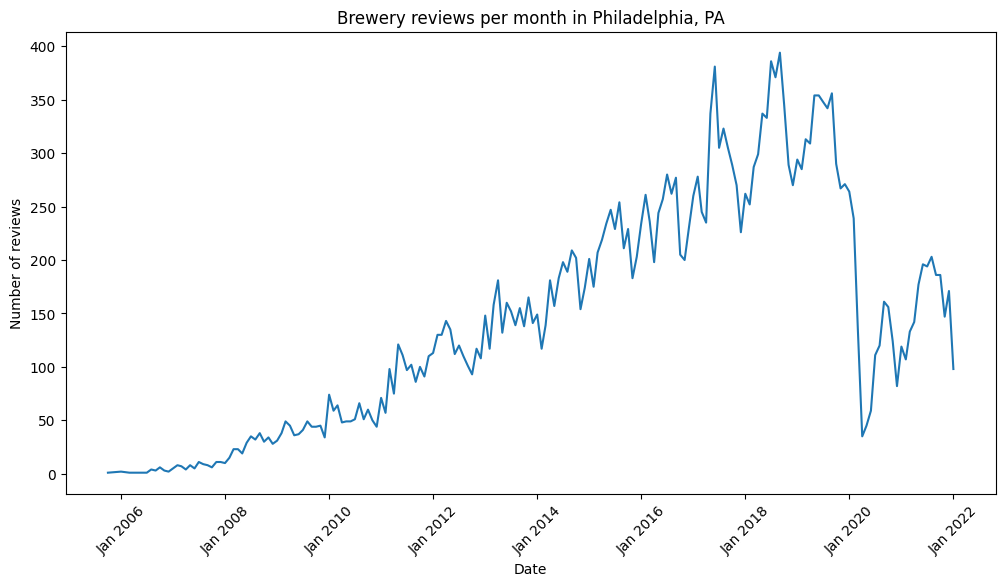

In [10]:
# plot number of brewery reviews across time
reviews['date'] = pd.to_datetime(reviews['date'])
breweries = reviews[reviews['brewery']== 1]


review_counts = breweries.groupby(breweries['date'].dt.to_period('M')).size().reset_index(name='n')
review_counts['date'] = review_counts['date'].dt.to_timestamp()
review_counts.set_index("date", inplace=True)

plt.figure(figsize=(12, 6))
plt.plot(review_counts['n'])
plt.xlabel("Date")
plt.ylabel("Number of reviews")
plt.title("Brewery reviews per month in Philadelphia, PA")

plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
plt.gca().xaxis.set_major_locator(mdates.AutoDateLocator())
plt.xticks(rotation=45)
plt.show()

## Subset to pre-2010 reviews and post-2020 reviews

In [11]:
# reproject
reviews = reviews.to_crs("EPSG:2272")
reviews.crs

<Projected CRS: EPSG:2272>
Name: NAD83 / Pennsylvania South (ftUS)
Axis Info [cartesian]:
- X[east]: Easting (US survey foot)
- Y[north]: Northing (US survey foot)
Area of Use:
- name: United States (USA) - Pennsylvania - counties of Adams; Allegheny; Armstrong; Beaver; Bedford; Berks; Blair; Bucks; Butler; Cambria; Chester; Cumberland; Dauphin; Delaware; Fayette; Franklin; Fulton; Greene; Huntingdon; Indiana; Juniata; Lancaster; Lawrence; Lebanon; Lehigh; Mifflin; Montgomery; Northampton; Perry; Philadelphia; Schuylkill; Snyder; Somerset; Washington; Westmoreland; York.
- bounds: (-80.53, 39.71, -74.72, 41.18)
Coordinate Operation:
- name: SPCS83 Pennsylvania South zone (US survey foot)
- method: Lambert Conic Conformal (2SP)
Datum: North American Datum 1983
- Ellipsoid: GRS 1980
- Prime Meridian: Greenwich

In [12]:
reviews = reviews.drop(columns="index_right")

In [13]:
reviews_pre = reviews[reviews['date'] < '01-01-2010']
reviews_pre.head()

,business_id,name,address,city,state,postal_code_x,latitude,longitude,stars,review_count,...,LISTNAME,review_id,user_id,useful,funny,cool,text,date,geometry,brewery
26,MTSW4McQd7CbVtyjqoe9mw,St Honore Pastries,935 Race St,Philadelphia,PA,19107,39.955505,-75.155564,4.0,80,...,Chinatown,wvnwbqlnknJxYqRdx8NyfA,0_FWb5d-EkJVaP0GAr0gcQ,1.0,0.0,1.0,St Honore Pastries is another one of those pla...,2008-06-16 13:41:58,POINT (2695729.449 237331.978),0
29,MTSW4McQd7CbVtyjqoe9mw,St Honore Pastries,935 Race St,Philadelphia,PA,19107,39.955505,-75.155564,4.0,80,...,Chinatown,SdTToFir1AuicPiszpl-0w,Q5I2xTcaQ22bmE_mp2q_Rw,6.0,0.0,2.0,A nice Chinese bakery that gets you the goods....,2008-03-09 00:36:56,POINT (2695729.449 237331.978),0
34,MTSW4McQd7CbVtyjqoe9mw,St Honore Pastries,935 Race St,Philadelphia,PA,19107,39.955505,-75.155564,4.0,80,...,Chinatown,fI_dVXwDk_MtmCufRabMgg,nDFRVVcNLLUt-F_s0yBIPA,2.0,0.0,1.0,Arguably the best Chinese pastry shop in Phill...,2009-02-21 22:07:07,POINT (2695729.449 237331.978),0
39,MTSW4McQd7CbVtyjqoe9mw,St Honore Pastries,935 Race St,Philadelphia,PA,19107,39.955505,-75.155564,4.0,80,...,Chinatown,IYPyO3ltLyfvGTxZyL3lyQ,0_FWb5d-EkJVaP0GAr0gcQ,2.0,0.0,1.0,Stopped in yesterday while on an unsuccessful ...,2009-02-15 20:11:58,POINT (2695729.449 237331.978),0
49,MTSW4McQd7CbVtyjqoe9mw,St Honore Pastries,935 Race St,Philadelphia,PA,19107,39.955505,-75.155564,4.0,80,...,Chinatown,cVdcoQxfdXwwOBRu28rl3g,nnwBdqGHIAJQ5QX9lHOtrQ,1.0,0.0,1.0,One of the better places in Philadelphia China...,2009-01-27 14:42:24,POINT (2695729.449 237331.978),0


In [14]:
reviews_post = reviews[reviews['date'] > '12-31-2019']
reviews_post.head()

,business_id,name,address,city,state,postal_code_x,latitude,longitude,stars,review_count,...,LISTNAME,review_id,user_id,useful,funny,cool,text,date,geometry,brewery
40,MTSW4McQd7CbVtyjqoe9mw,St Honore Pastries,935 Race St,Philadelphia,PA,19107,39.955505,-75.155564,4.0,80,...,Chinatown,FpQ0osfFoRn6SlIpuQLllA,Te3BwftEFN8C9WxImhfM_g,1.0,0.0,2.0,We have tried many of the bakeries in Chinatow...,2020-03-18 15:22:01,POINT (2695729.449 237331.978),0
60,MTSW4McQd7CbVtyjqoe9mw,St Honore Pastries,935 Race St,Philadelphia,PA,19107,39.955505,-75.155564,4.0,80,...,Chinatown,quG4LkGyTZCfN2ZbnqVLVQ,6HMepXAIwsetCZKNvN2fdA,1.0,0.0,0.0,If I'm driving to Philly for some cheese steak...,2020-10-18 21:56:43,POINT (2695729.449 237331.978),0
61,MTSW4McQd7CbVtyjqoe9mw,St Honore Pastries,935 Race St,Philadelphia,PA,19107,39.955505,-75.155564,4.0,80,...,Chinatown,mhuACzNGUqI3cz0gPFalVw,ST97w3WYND_9uxcsexQuNA,0.0,0.0,0.0,Support this business! I grabbed 4 pastries he...,2020-06-07 01:50:34,POINT (2695729.449 237331.978),0
64,MTSW4McQd7CbVtyjqoe9mw,St Honore Pastries,935 Race St,Philadelphia,PA,19107,39.955505,-75.155564,4.0,80,...,Chinatown,gQSJzOAR-eFCntXyFiRk6Q,fyugYI0E5B9rLxgA0Cn7ZQ,0.0,0.0,0.0,I love this place.. I love their chunky fried...,2020-05-25 16:27:36,POINT (2695729.449 237331.978),0
68,MTSW4McQd7CbVtyjqoe9mw,St Honore Pastries,935 Race St,Philadelphia,PA,19107,39.955505,-75.155564,4.0,80,...,Chinatown,x2ldjXFGq1uW7s0Ktdl2Yg,ntqURA0yzrFadofEZNwIyw,2.0,0.0,3.0,They are still open and fully stocked during t...,2020-05-16 17:37:05,POINT (2695729.449 237331.978),0


In [15]:
# check number of reviews in subsetted data
print(reviews_pre.shape[0])
print(reviews_post.shape[0])

34610
73266


In [16]:
print(np.mean(reviews_pre['brewery'] == 1))
print(np.mean(reviews_post['brewery'] == 1))

0.026784166425888472
0.04914967379139028


## Join with census tract gentrification indicators

In [17]:
tracts_2010 = gpd.read_file("data/phillytracts2010_gentrif.geojson")
tracts_2010.head() 

,FID,OBJECTID,STATEFP10,COUNTYFP10,TRACTCE10,GEOID10,NAME10,NAMELSAD10,MTFCC10,FUNCSTAT10,ALAND10,AWATER10,INTPTLAT10,INTPTLON10,LOGRECNO,SHAPE_AREA,SHAPE_LEN,GentYN,geometry
0,0,46,42,101,005000,42101005000,50,Census Tract 50,G5020,S,4504459,3340294,+39.8898768,-075.1691412,10389,8.832943e+07,48033.335048,0,"POLYGON ((-75.17215 39.88129, -75.16966 39.881..."
1,1,47,42,101,005400,42101005400,54,Census Tract 54,G5020,S,1846253,530013,+39.8904539,-075.2513923,10390,2.575213e+07,24624.823144,0,"POLYGON ((-75.24623 39.88951, -75.24585 39.889..."
2,2,48,42,101,005500,42101005500,55,Census Tract 55,G5020,S,1168442,12010,+39.9074191,-075.2489174,10391,1.270364e+07,20389.059940,0,"POLYGON ((-75.25129 39.90441, -75.25179 39.903..."
3,3,49,42,101,005600,42101005600,56,Census Tract 56,G5020,S,840411,0,+39.8988328,-075.2447347,10392,9.047139e+06,11788.147571,0,"POLYGON ((-75.24184 39.90384, -75.24196 39.903..."
4,4,50,42,101,006000,42101006000,60,Census Tract 60,G5020,S,1089657,0,+39.9115196,-075.2381570,10393,1.175557e+07,14205.267812,0,"POLYGON ((-75.23342 39.91385, -75.23369 39.914..."


In [18]:
tracts_2010.columns

Index(['FID', 'OBJECTID', 'STATEFP10', 'COUNTYFP10', 'TRACTCE10', 'GEOID10',
       'NAME10', 'NAMELSAD10', 'MTFCC10', 'FUNCSTAT10', 'ALAND10', 'AWATER10',
       'INTPTLAT10', 'INTPTLON10', 'LOGRECNO', 'SHAPE_AREA', 'SHAPE_LEN',
       'GentYN', 'geometry'],
      dtype='object')

In [19]:
tracts_2020 = gpd.read_file("data/phillytracts2020_gentrif.geojson")
tracts_2020.head() 

,FID,STATEFP,COUNTYFP,TRACTCE,GEOID,NAME,NAMELSAD,MTFCC,FUNCSTAT,ALAND,AWATER,INTPTLAT,INTPTLON,GentYN,geometry
0,0,42,101,012204,42101012204,122.04,Census Tract 122.04,G5020,S,879459,56473,+40.0009407,-075.2120769,0,"POLYGON ((-75.22067 40.00395, -75.2205 40.0033..."
1,1,42,101,012203,42101012203,122.03,Census Tract 122.03,G5020,S,227696,0,+40.0074872,-075.2093403,0,"POLYGON ((-75.21389 40.00549, -75.21403 40.005..."
2,2,42,101,013602,42101013602,136.02,Census Tract 136.02,G5020,S,246812,0,+39.9716057,-075.1800748,0,"POLYGON ((-75.18637 39.97355, -75.18606 39.972..."
3,3,42,101,034502,42101034502,345.02,Census Tract 345.02,G5020,S,1021734,0,+40.0814101,-075.0384569,0,"POLYGON ((-75.04729 40.08294, -75.04708 40.082..."
4,4,42,101,000902,42101000902,9.02,Census Tract 9.02,G5020,S,155167,0,+39.9471596,-075.1566389,0,"POLYGON ((-75.16017 39.94687, -75.16027 39.946..."


In [20]:

# reproject
tracts_2010 = tracts_2010.to_crs(reviews_pre.crs)
tracts_2020 = tracts_2020.to_crs(reviews_post.crs)

In [98]:
# spatial join with reviews data
reviews_tracts10 = reviews_pre.sjoin(tracts_2010[["GentYN", "TRACTCE10", "GEOID10", "geometry"]], how = "left",predicate= "intersects")
reviews_tracts10.head()

,business_id,name,address,city,state,postal_code_x,latitude,longitude,stars,review_count,...,funny,cool,text,date,geometry,brewery,index_right,GentYN,TRACTCE10,GEOID10
26,MTSW4McQd7CbVtyjqoe9mw,St Honore Pastries,935 Race St,Philadelphia,PA,19107,39.955505,-75.155564,4.0,80,...,0.0,1.0,St Honore Pastries is another one of those pla...,2008-06-16 13:41:58,POINT (2695729.449 237331.978),0,145.0,0.0,000200,42101000200
29,MTSW4McQd7CbVtyjqoe9mw,St Honore Pastries,935 Race St,Philadelphia,PA,19107,39.955505,-75.155564,4.0,80,...,0.0,2.0,A nice Chinese bakery that gets you the goods....,2008-03-09 00:36:56,POINT (2695729.449 237331.978),0,145.0,0.0,000200,42101000200
34,MTSW4McQd7CbVtyjqoe9mw,St Honore Pastries,935 Race St,Philadelphia,PA,19107,39.955505,-75.155564,4.0,80,...,0.0,1.0,Arguably the best Chinese pastry shop in Phill...,2009-02-21 22:07:07,POINT (2695729.449 237331.978),0,145.0,0.0,000200,42101000200
39,MTSW4McQd7CbVtyjqoe9mw,St Honore Pastries,935 Race St,Philadelphia,PA,19107,39.955505,-75.155564,4.0,80,...,0.0,1.0,Stopped in yesterday while on an unsuccessful ...,2009-02-15 20:11:58,POINT (2695729.449 237331.978),0,145.0,0.0,000200,42101000200
49,MTSW4McQd7CbVtyjqoe9mw,St Honore Pastries,935 Race St,Philadelphia,PA,19107,39.955505,-75.155564,4.0,80,...,0.0,1.0,One of the better places in Philadelphia China...,2009-01-27 14:42:24,POINT (2695729.449 237331.978),0,145.0,0.0,000200,42101000200


In [99]:
reviews_tracts20 = reviews_post.sjoin(tracts_2020[["GentYN", "TRACTCE", "GEOID", "geometry"]], how = "left",predicate= "intersects")
reviews_tracts20.head()

,business_id,name,address,city,state,postal_code_x,latitude,longitude,stars,review_count,...,funny,cool,text,date,geometry,brewery,index_right,GentYN,TRACTCE,GEOID
40,MTSW4McQd7CbVtyjqoe9mw,St Honore Pastries,935 Race St,Philadelphia,PA,19107,39.955505,-75.155564,4.0,80,...,0.0,2.0,We have tried many of the bakeries in Chinatow...,2020-03-18 15:22:01,POINT (2695729.449 237331.978),0,275.0,0.0,000200,42101000200
60,MTSW4McQd7CbVtyjqoe9mw,St Honore Pastries,935 Race St,Philadelphia,PA,19107,39.955505,-75.155564,4.0,80,...,0.0,0.0,If I'm driving to Philly for some cheese steak...,2020-10-18 21:56:43,POINT (2695729.449 237331.978),0,275.0,0.0,000200,42101000200
61,MTSW4McQd7CbVtyjqoe9mw,St Honore Pastries,935 Race St,Philadelphia,PA,19107,39.955505,-75.155564,4.0,80,...,0.0,0.0,Support this business! I grabbed 4 pastries he...,2020-06-07 01:50:34,POINT (2695729.449 237331.978),0,275.0,0.0,000200,42101000200
64,MTSW4McQd7CbVtyjqoe9mw,St Honore Pastries,935 Race St,Philadelphia,PA,19107,39.955505,-75.155564,4.0,80,...,0.0,0.0,I love this place.. I love their chunky fried...,2020-05-25 16:27:36,POINT (2695729.449 237331.978),0,275.0,0.0,000200,42101000200
68,MTSW4McQd7CbVtyjqoe9mw,St Honore Pastries,935 Race St,Philadelphia,PA,19107,39.955505,-75.155564,4.0,80,...,0.0,3.0,They are still open and fully stocked during t...,2020-05-16 17:37:05,POINT (2695729.449 237331.978),0,275.0,0.0,000200,42101000200


In [100]:
print(reviews_tracts10.shape[0]) # should be 34610
print(reviews_tracts20.shape[0]) # should be 73266


34610
73266


In [105]:
print(sum(reviews_tracts10['GEOID10'].isna()))
na_tracts_2010 = reviews_tracts10[reviews_tracts10['GEOID10'].isna()]
na_tracts_2010['address'].unique()

46


array(['7620 Ridge Ave', '9800 Germantown Pike', '9165 Ridge Pike',
       '2385 W Cheltenham Ave', '115 W City Ave', '1508 S St'],
      dtype=object)

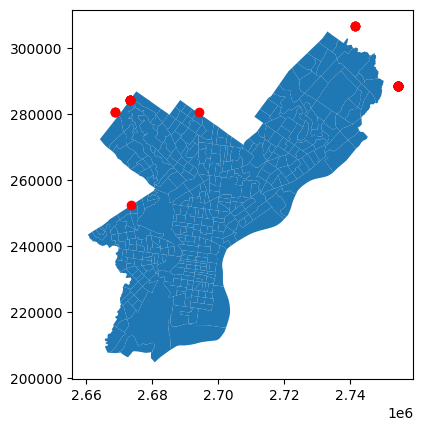

In [107]:
# Plot the reviews that fell outside of Philly boundaries
fig, ax = plt.subplots()

tracts_2010.plot(ax=ax)
na_tracts_2010.plot(ax=ax, color="red")

plt.show()

In [101]:
print(sum(reviews_tracts20['GEOID'].isna()))
na_tracts_2020 = reviews_tracts20[reviews_tracts20['GEOID'].isna()]
na_tracts_2020['address'].unique()

116


array(['232 N Radnor Chester Rd',
       '8500 Essington Ave, Philadelphia International Airport, Terminal A',
       '2401 Cheltenham Ave',
       '8500 Essington Ave, Terminal A, Philadelphia International Airport',
       'Philadelphia International Airport', '3110 W Cheltenham Ave',
       '9800 Germantown Pike', '8000 Essington Ave, Terminal E',
       '8500 Essington Ave, Ste FH-7',
       '8000 Essington Ave, Terminal C, Philadelphia Airport',
       '2385 W Cheltenham Ave', '12TH And Arch St',
       '2451 W Cheltenham Ave'], dtype=object)

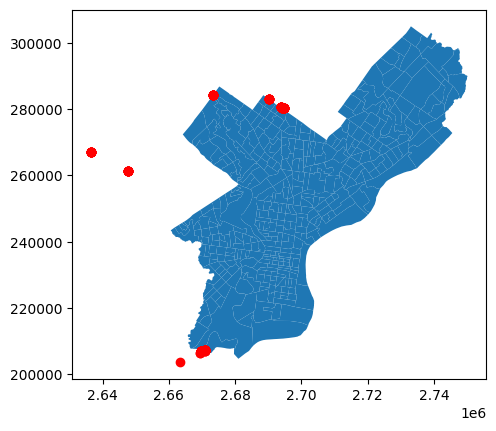

In [ ]:
# Plot the reviews that fell outside of Philly boundaries
fig, ax = plt.subplots()

tracts_2020.plot(ax=ax)
na_tracts_2020.plot(ax=ax, color="red")

plt.show()

In [109]:
# drop the reviews that are outside of Philly boundaries
reviews_tracts20 = reviews_tracts20.dropna(subset=['GEOID'])
print(reviews_tracts20.shape[0])

reviews_tracts10 = reviews_tracts10.dropna(subset=['GEOID10'])
print(reviews_tracts10.shape[0])

73150
34564


## Gentrified/Brewery Time Series Plots

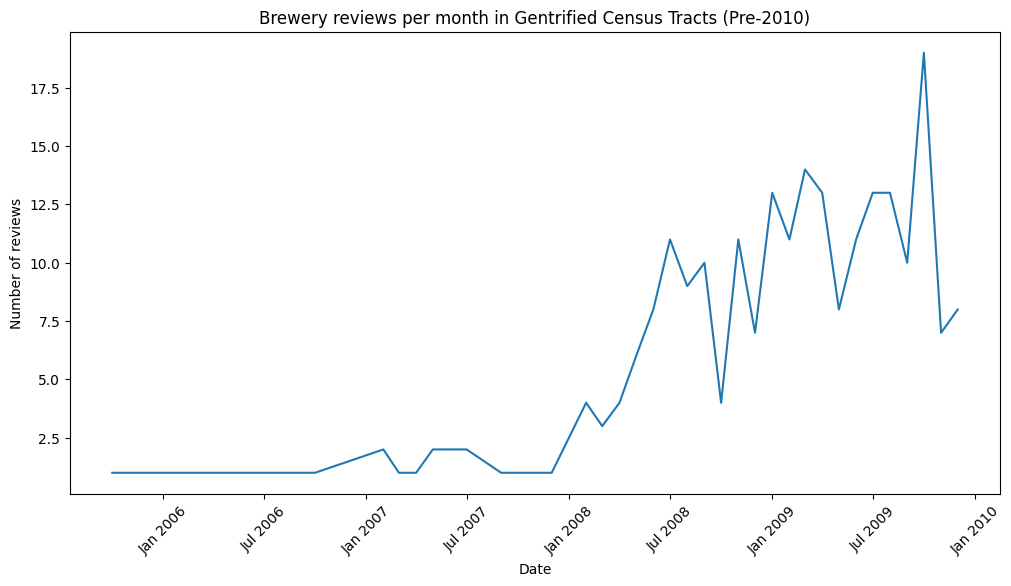

In [24]:
gent_brew10 = reviews_tracts10[(reviews_tracts10['GentYN'] == 1) & (reviews_tracts10['brewery'] == 1)]

gent_brew_counts10 = gent_brew10.groupby(gent_brew10['date'].dt.to_period('M')).size().reset_index(name='n')
gent_brew_counts10['date'] = gent_brew_counts10['date'].dt.to_timestamp()
gent_brew_counts10.set_index("date", inplace=True)

plt.figure(figsize=(12, 6))
plt.plot(gent_brew_counts10['n'])
plt.xlabel("Date")
plt.ylabel("Number of reviews")
plt.title("Brewery reviews per month in Gentrified Census Tracts (Pre-2010)")

plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
plt.gca().xaxis.set_major_locator(mdates.AutoDateLocator())
plt.xticks(rotation=45)
plt.show()

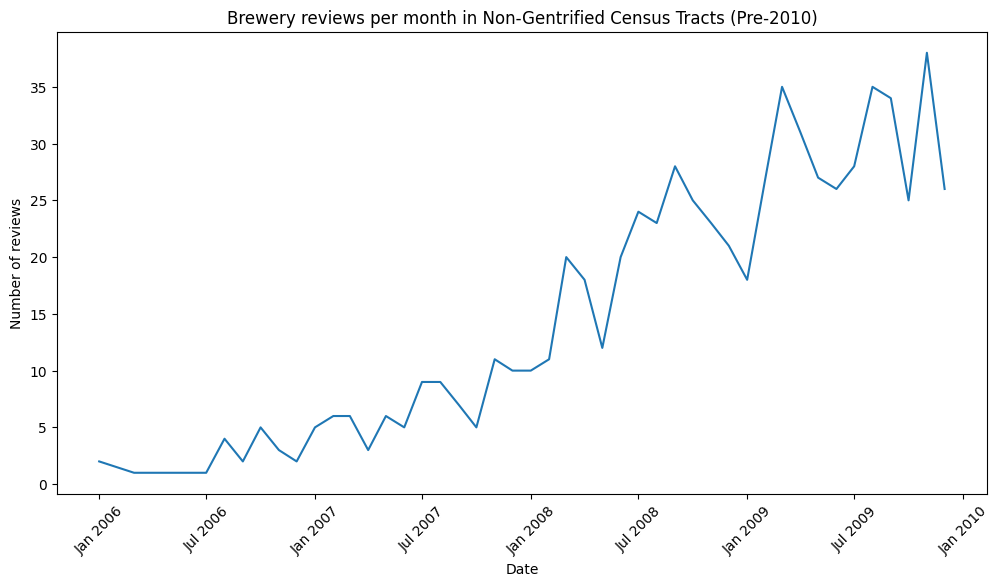

In [26]:
ng_brew10 = reviews_tracts10[(reviews_tracts10['GentYN'] == 0) & (reviews_tracts10['brewery'] == 1)]

ng_brew_counts10 = ng_brew10.groupby(ng_brew10['date'].dt.to_period('M')).size().reset_index(name='n')
ng_brew_counts10['date'] = ng_brew_counts10['date'].dt.to_timestamp()
ng_brew_counts10.set_index("date", inplace=True)

plt.figure(figsize=(12, 6))
plt.plot(ng_brew_counts10['n'])
plt.xlabel("Date")
plt.ylabel("Number of reviews")
plt.title("Brewery reviews per month in Non-Gentrified Census Tracts (Pre-2010)")

plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
plt.gca().xaxis.set_major_locator(mdates.AutoDateLocator())
plt.xticks(rotation=45)
plt.show()

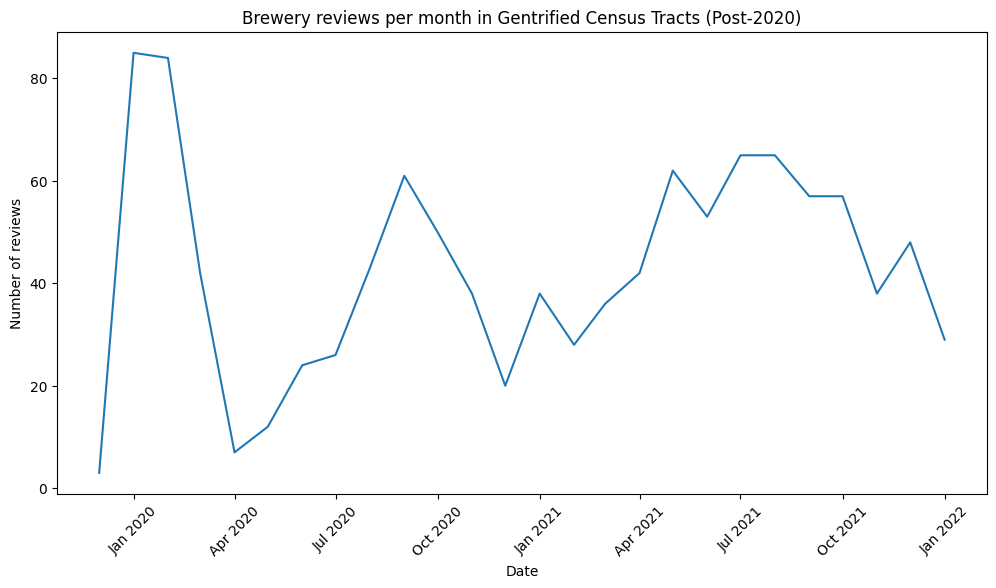

In [27]:
gent_brew20 = reviews_tracts20[(reviews_tracts20['GentYN'] == 1) & (reviews_tracts20['brewery'] == 1)]

gent_brew_counts20 = gent_brew20.groupby(gent_brew20['date'].dt.to_period('M')).size().reset_index(name='n')
gent_brew_counts20['date'] = gent_brew_counts20['date'].dt.to_timestamp()
gent_brew_counts20.set_index("date", inplace=True)

plt.figure(figsize=(12, 6))
plt.plot(gent_brew_counts20['n'])
plt.xlabel("Date")
plt.ylabel("Number of reviews")
plt.title("Brewery reviews per month in Gentrified Census Tracts (Post-2020)")

plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
plt.gca().xaxis.set_major_locator(mdates.AutoDateLocator())
plt.xticks(rotation=45)
plt.show()

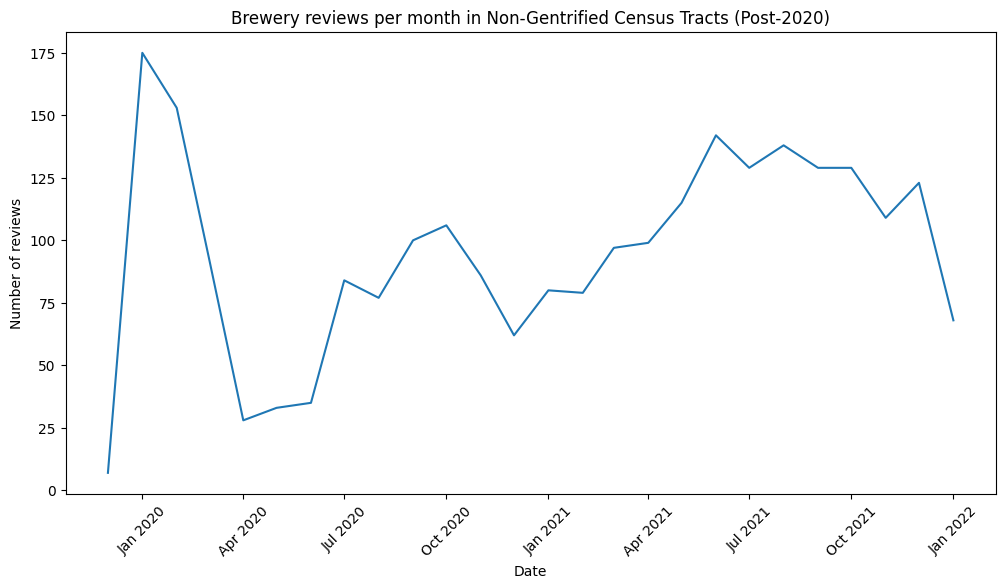

In [29]:
ng_brew20 = reviews_tracts20[(reviews_tracts20['GentYN'] == 0) & (reviews_tracts20['brewery'] == 1)]

ng_brew_counts20 = ng_brew20.groupby(ng_brew20['date'].dt.to_period('M')).size().reset_index(name='n')
ng_brew_counts20['date'] = ng_brew_counts20['date'].dt.to_timestamp()
ng_brew_counts20.set_index("date", inplace=True)

plt.figure(figsize=(12, 6))
plt.plot(ng_brew_counts20['n'])
plt.xlabel("Date")
plt.ylabel("Number of reviews")
plt.title("Brewery reviews per month in Non-Gentrified Census Tracts (Post-2020)")

plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
plt.gca().xaxis.set_major_locator(mdates.AutoDateLocator())
plt.xticks(rotation=45)
plt.show()

## Join with census demographic/socioeconomic data

In [118]:
demog_2010 = gpd.read_file("data/tracts_demog_2010.geojson")
demog_2020= gpd.read_file("data/tracts_demog_2020.geojson")

In [31]:
demog_2010.head()

,GEO_ID,tot_pop,prop_black,prop_asian,prop_hispanic_or_latino,prop_white_only,med_prop_val,med_inc,total_25_plus,pct_bachelor_or_higher,pct_bachelor_lower,GentYN,geometry
0,42101036301,3695.0,0.043572,0.191610,0.066576,0.698241,201900.0,54569.0,2604.0,15.6,84.4,0,"POLYGON ((2748366.299 290799.127, 2748435.97 2..."
1,42101036400,703.0,0.216216,0.028450,0.024182,0.731152,NaN,NaN,393.0,1.8,98.2,0,"POLYGON ((2743809.154 294040.402, 2743494.584 ..."
2,42101036600,1643.0,0.065733,0.227632,0.038953,0.667681,436500.0,130139.0,1139.0,75.4,24.6,0,"POLYGON ((2699720.168 236062.074, 2699719.035 ..."
3,42101034803,4390.0,0.068109,0.057859,0.052392,0.821640,208000.0,56667.0,3305.0,19.9,80.1,0,"POLYGON ((2735668.565 276129.136, 2735577.548 ..."
4,42101034702,3807.0,0.073286,0.097189,0.064618,0.764907,219800.0,69981.0,3300.0,28.3,71.7,0,"POLYGON ((2730958.367 278534.172, 2730985.876 ..."


In [89]:
demog_2020.head()

,GEO_ID,tot_pop,prop_black,prop_asian,prop_hispanic_or_latino,prop_white_only,med_prop_val,med_inc,total_25_plus,pct_bachelor_or_higher,pct_bachelor_lower,GentYN,geometry
0,42101012204,3694,0.728479,0.050893,0.041960,0.178668,27245.0,56495.0,3219,44.920783,55.079217,0,"POLYGON ((2676981.178 254440.769, 2677375.454 ..."
1,42101012203,658,0.255319,0.256839,0.048632,0.439210,NaN,52209.0,626,65.495208,34.504792,0,"POLYGON ((2678861.975 255056.314, 2678866.419 ..."
2,42101013602,3776,0.071769,0.062500,0.049523,0.816208,27378.0,92212.0,3269,83.328235,16.671765,0,"POLYGON ((2686906.79 243645.714, 2686997.702 2..."
3,42101034502,5928,0.207659,0.191464,0.068657,0.532220,33666.0,47714.0,3940,41.573604,58.426396,0,"POLYGON ((2724650.476 284639.902, 2724859.044 ..."
4,42101000902,2842,0.065799,0.245602,0.034131,0.654469,260311.0,61312.0,2251,69.258108,30.741892,0,"POLYGON ((2694530.584 234145.037, 2694537.691 ..."


In [97]:
reviews_tracts10.columns

Index(['business_id', 'name', 'address', 'city', 'state', 'postal_code_x',
       'latitude', 'longitude', 'stars', 'review_count', 'is_open',
       'attributes', 'categories', 'hours', 'LISTNAME', 'review_id', 'user_id',
       'useful', 'funny', 'cool', 'text', 'date', 'geometry', 'brewery',
       'index_right', 'GentYN', 'TRACTCE10', 'GEO_ID'],
      dtype='object')

In [119]:
reviews_tracts10['GEOID10'] = reviews_tracts10['GEOID10'].astype(int)
reviews_tracts20['GEOID'] = reviews_tracts20['GEOID'].astype(int)

reviews_tracts10.dtypes

KeyError: 'GEOID10'

In [40]:
reviews_tracts10.dtypes

business_id              object
name                     object
address                  object
city                     object
state                    object
postal_code_x            object
latitude                float64
longitude               float64
stars                   float64
review_count              int64
is_open                   int64
attributes               object
categories               object
hours                    object
LISTNAME                 object
review_id                object
user_id                  object
useful                  float64
funny                   float64
cool                    float64
text                     object
date             datetime64[ns]
geometry               geometry
brewery                   int64
index_right             float64
GentYN                  float64
TRACTCE10                object
GEO_ID                   object
dtype: object

In [120]:
demog_2010 =demog_2010.drop(columns=["GentYN", "geometry"])
demog_2020 =demog_2020.drop(columns=["GentYN", "geometry"])
# join reviews_tracts10 with demog_2010
reviews_tracts10 = reviews_tracts10.rename(columns={"GEOID10": "GEO_ID"})
reviews_tracts20 = reviews_tracts20.rename(columns={"GEOID": "GEO_ID"})

# outer to keep the census tracts without any reviews
reviews_demog10 = reviews_tracts10.merge(demog_2010, how="outer", on="GEO_ID")
reviews_demog20 = reviews_tracts20.merge(demog_2020, how="outer", on="GEO_ID")

In [121]:
print(reviews_demog10.shape[0]) 
print(reviews_demog20.shape[0]) 



34702
73206


In [122]:

print(demog_2020['GEO_ID'].duplicated().sum()) # 23 duplicated GEO_IDs
demog_2020[demog_2020['GEO_ID'].duplicated(keep=False)]

0


,GEO_ID,tot_pop,prop_black,prop_asian,prop_hispanic_or_latino,prop_white_only,med_prop_val,med_inc,total_25_plus,pct_bachelor_or_higher,pct_bachelor_lower


In [123]:


print(demog_2010['GEO_ID'].duplicated().sum()) # 0 duplicated GEO_IDs
demog_2010[demog_2010['GEO_ID'].duplicated(keep=False)]

0


,GEO_ID,tot_pop,prop_black,prop_asian,prop_hispanic_or_latino,prop_white_only,med_prop_val,med_inc,total_25_plus,pct_bachelor_or_higher,pct_bachelor_lower


In [124]:
print(reviews_tracts20['GEO_ID'].unique().shape[0])
print(reviews_demog20['GEO_ID'].unique().shape[0])
print(demog_2020.shape[0])

352
408
408


In [125]:
reviews_demog10.head()

,business_id,name,address,city,state,postal_code_x,latitude,longitude,stars,review_count,...,tot_pop,prop_black,prop_asian,prop_hispanic_or_latino,prop_white_only,med_prop_val,med_inc,total_25_plus,pct_bachelor_or_higher,pct_bachelor_lower
0,XgLrkmIqIrD_pl67lAovEQ,The Bourse,111 S Independence Mall E,Philadelphia,PA,19106,39.949819,-75.148655,2.0,35.0,...,3478.0,0.06383,0.125359,0.036228,0.774583,354800.0,73041.0,2752.0,72.3,27.7
1,XgLrkmIqIrD_pl67lAovEQ,The Bourse,111 S Independence Mall E,Philadelphia,PA,19106,39.949819,-75.148655,2.0,35.0,...,3478.0,0.06383,0.125359,0.036228,0.774583,354800.0,73041.0,2752.0,72.3,27.7
2,XgLrkmIqIrD_pl67lAovEQ,The Bourse,111 S Independence Mall E,Philadelphia,PA,19106,39.949819,-75.148655,2.0,35.0,...,3478.0,0.06383,0.125359,0.036228,0.774583,354800.0,73041.0,2752.0,72.3,27.7
3,XgLrkmIqIrD_pl67lAovEQ,The Bourse,111 S Independence Mall E,Philadelphia,PA,19106,39.949819,-75.148655,2.0,35.0,...,3478.0,0.06383,0.125359,0.036228,0.774583,354800.0,73041.0,2752.0,72.3,27.7
4,XgLrkmIqIrD_pl67lAovEQ,The Bourse,111 S Independence Mall E,Philadelphia,PA,19106,39.949819,-75.148655,2.0,35.0,...,3478.0,0.06383,0.125359,0.036228,0.774583,354800.0,73041.0,2752.0,72.3,27.7


In [126]:
reviews_demog20.head()

,business_id,name,address,city,state,postal_code_x,latitude,longitude,stars,review_count,...,tot_pop,prop_black,prop_asian,prop_hispanic_or_latino,prop_white_only,med_prop_val,med_inc,total_25_plus,pct_bachelor_or_higher,pct_bachelor_lower
0,5m3ND7lNNd6zo-bNQGoXhQ,Three 12 Sport Bar and Lounge,312 Market St,Philadelphia,PA,19106,39.949945,-75.146352,2.5,33.0,...,2329,0.054959,0.101331,0.055818,0.787892,93462.0,104458.0,1708,91.627635,8.372365
1,5m3ND7lNNd6zo-bNQGoXhQ,Three 12 Sport Bar and Lounge,312 Market St,Philadelphia,PA,19106,39.949945,-75.146352,2.5,33.0,...,2329,0.054959,0.101331,0.055818,0.787892,93462.0,104458.0,1708,91.627635,8.372365
2,5m3ND7lNNd6zo-bNQGoXhQ,Three 12 Sport Bar and Lounge,312 Market St,Philadelphia,PA,19106,39.949945,-75.146352,2.5,33.0,...,2329,0.054959,0.101331,0.055818,0.787892,93462.0,104458.0,1708,91.627635,8.372365
3,5m3ND7lNNd6zo-bNQGoXhQ,Three 12 Sport Bar and Lounge,312 Market St,Philadelphia,PA,19106,39.949945,-75.146352,2.5,33.0,...,2329,0.054959,0.101331,0.055818,0.787892,93462.0,104458.0,1708,91.627635,8.372365
4,5m3ND7lNNd6zo-bNQGoXhQ,Three 12 Sport Bar and Lounge,312 Market St,Philadelphia,PA,19106,39.949945,-75.146352,2.5,33.0,...,2329,0.054959,0.101331,0.055818,0.787892,93462.0,104458.0,1708,91.627635,8.372365


In [127]:
reviews_demog10.crs

<Projected CRS: EPSG:2272>
Name: NAD83 / Pennsylvania South (ftUS)
Axis Info [cartesian]:
- X[east]: Easting (US survey foot)
- Y[north]: Northing (US survey foot)
Area of Use:
- name: United States (USA) - Pennsylvania - counties of Adams; Allegheny; Armstrong; Beaver; Bedford; Berks; Blair; Bucks; Butler; Cambria; Chester; Cumberland; Dauphin; Delaware; Fayette; Franklin; Fulton; Greene; Huntingdon; Indiana; Juniata; Lancaster; Lawrence; Lebanon; Lehigh; Mifflin; Montgomery; Northampton; Perry; Philadelphia; Schuylkill; Snyder; Somerset; Washington; Westmoreland; York.
- bounds: (-80.53, 39.71, -74.72, 41.18)
Coordinate Operation:
- name: SPCS83 Pennsylvania South zone (US survey foot)
- method: Lambert Conic Conformal (2SP)
Datum: North American Datum 1983
- Ellipsoid: GRS 1980
- Prime Meridian: Greenwich

In [ ]:
reviews_demog10.to_file("data/reviews_demog10.gpkg")